# Ad Spend & Causal Inference — From OLS to MMM & GeoLift
### Iteration 3 · European label · daily Spotify streams + paid-social spend

**Where we are.** Iterations 1–2 simulated releases and daily streams. Now the label
adds **paid-social spend** (TikTok, Instagram) and wants **causal** answers, not
correlations: *how many streams did the ads actually cause?*

**Data sources (assumed first-party).**
- **Streams** — daily, per country, from **Spotify for Artists / S4A API** (the label's own).
- **Spend** — daily, per country, per channel, from the **TikTok / Meta Ads** APIs.

> **Why this is hard.** Spend is **not random**. The label funds the releases and the
> moments it already expects to do well, and it tends to push paid media into the
> *post-launch decay phase* to prop up a fading song. So raw correlation between spend
> and streams is **confounded** — and as we'll see, it can even come out *negative*.
> Every rung of the ladder builds a more credible **counterfactual** (what would
> streams have been *without* the ads?).

## The five causal questions
1. **Incrementality** — extra streams *caused* by paid social vs. the organic baseline → **iROAS** (streams/€), cost-per-incremental-stream.
2. **Channel effectiveness (MMM)** — each channel's contribution with **adstock** (carryover) + **saturation** (diminishing returns); marginal ROAS; budget reallocation.
3. **Per-campaign geo-lift** — effect of switching spend on in some countries.
4. **Heterogeneity** — by artist tier, country, channel, release phase.
5. **Dynamics** — adstock length; does advertising extend the release tail?

## The estimand
The **ATT**: the **% lift in streams in treated geos during the campaign**, and the
**iROAS**. Because this is synthetic, we **bake in the true effect** and score every
estimator against it.

## The ladder (basic → ideal) and what each one buys you
| # | Method | Identifying assumption | Fixes | Tool |
|---|---|---|---|---|
| 0 | Naive OLS / pre-post | none (correlation) | — | statsmodels |
| 1 | TWFE on spend | selection on FE only | unit/time levels | pyfixest |
| 2 | DiD 2×2 | parallel trends | common shocks | pyfixest |
| 3 | Staggered DiD (Sun–Abraham) | parallel trends, no-anticipation | **staggered-timing bias** | pyfixest |
| 4 | Synthetic Control | convex pre-fit of donors | one treated unit, weights | pysyncon |
| 5 | Synthetic DiD | unit **and** time weights | robustness, bias | from scratch |
| 6 | Augmented SCM (**GeoLift** core) | ridge-relaxed fit | poor pre-fit / extrapolation | pysyncon |
| 7 | Bayesian SC | as SC + priors | **uncertainty** | CausalPy |
| 8 | **Bayesian MMM** | adstock+Hill, calibrated | always-on budget, all channels | pymc-marketing |

We use the real production libraries the way you would on the job; `synthdid` has no
maintained Python port, so it's implemented from scratch (and we cite the R original).


## 1 · Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import logging; logging.disable(logging.WARNING)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
plt.rcParams.update({"figure.figsize":(11,4.5),"figure.dpi":110,"axes.grid":True,
    "grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False,"font.size":11})
BLUE,RED,GREEN,GREY = "#3b6fb0","#d1495b","#66a182","#9e9e9e"
RNG_SEED = 7

## 2 · The data-generating process (with known ground truth)

A **country × day** panel of streams for one **flagship single** launched across **12
European markets**, observed for 17 weeks.

- **Organic** streams = market-size × release spike × exponential decay × weekly
  seasonality × a **common** national shock (so geos co-move — essential for DiD/SC).
- **Paid boost** rolls out **staggered**: 8 treated countries in 3 cohorts (start days
  28 / 42 / 56), and **4 held-out controls** (FR, NL, PT, DK) — a classic geo holdout.
- **Incremental** streams = `Hill(adstock(spend))` per channel, with **known**
  carryover (θ) and saturation — this is the causal effect we'll try to recover.
- **Confounding**: spend ramps *during the decay phase*, so naive spend↔streams
  correlation is negative.


In [2]:
def adstock(x, theta):
    out = np.empty_like(x, float); acc = 0.0
    for i, v in enumerate(x):
        acc = v + theta*acc; out[i] = acc
    return out

def hill(x, alpha, kappa):
    xa = np.power(np.maximum(x,0), alpha)
    return xa/(xa + np.power(kappa, alpha))

def make_data(seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    geo = pd.DataFrame({"country":["DE","FR","ES","IT","NL","SE","PL","BE","AT","PT","IE","DK"],
                        "size":[1.00,0.85,0.70,0.65,0.45,0.40,0.50,0.30,0.28,0.25,0.20,0.22]})
    t0 = pd.Timestamp("2026-03-06"); days = pd.date_range(t0, periods=119, freq="D")
    T = len(days); a = np.arange(T)
    control = ["FR","NL","PT","DK"]
    cohorts = {28:["DE","ES"], 42:["IT","PL","BE"], 56:["SE","AT","IE"]}
    start_day = {c:g for g,cs in cohorts.items() for c in cs}
    for c in control: start_day[c] = None
    lam = np.log(2)/30.0
    weekly = np.array([0.95,0.93,0.95,1.00,1.18,1.14,1.06]); weekly/=weekly.mean()
    nat_shock = np.exp(np.cumsum(rng.normal(0,0.03,T)) + rng.normal(0,0.02,T))
    base_peak = 60000.0
    THETA = {"tiktok":0.55,"instagram":0.45}; VMAX = {"tiktok":3500.0,"instagram":1800.0}
    ALPHA, KAPPA = 1.0, 600.0
    rows = []
    for _, gr in geo.iterrows():
        c, size = gr.country, gr.size
        organic = base_peak*size*np.exp(-lam*a)*weekly[days.weekday]*nat_shock*np.exp(rng.normal(0,0.05,T))
        sd = start_day[c]; spend = {ch:np.zeros(T) for ch in THETA}
        if sd is not None:
            prof = np.where(a>=sd, np.minimum((a-sd+1)/7,1)*np.exp(-(np.maximum(a-sd-7,0))/70),0)
            spend["tiktok"]    = prof*(120*size)*np.exp(rng.normal(0,0.1,T))
            spend["instagram"] = prof*(80*size)*np.exp(rng.normal(0,0.1,T))
        incr = np.zeros(T)
        for ch in THETA:
            incr += VMAX[ch]*size*hill(adstock(spend[ch], THETA[ch]), ALPHA, KAPPA)
        streams = rng.poisson(np.maximum(organic+incr,0.1)).astype(float)
        for i in range(T):
            rows.append(dict(country=c, size=size, date=days[i], t=i,
                treated=int(sd is not None), start_day=(sd if sd else -1),
                post=int(sd is not None and i>=sd), tiktok=spend["tiktok"][i],
                instagram=spend["instagram"][i], organic=organic[i],
                incremental=incr[i], streams=streams[i]))
    df = pd.DataFrame(rows); df["spend"] = df.tiktok + df.instagram
    df["ly"] = np.log(df.streams.clip(lower=1))
    meta = dict(days=days, geo=geo, control=control, cohorts=cohorts, start_day=start_day,
                THETA=THETA, VMAX=VMAX, ALPHA=ALPHA, KAPPA=KAPPA)
    return df, meta

df, meta = make_data()
print("panel:", df.shape, "| countries:", df.country.nunique(), "| days:", df.t.nunique())
df.head()

panel: (1428, 14) | countries: 12 | days: 119


,country,size,date,t,treated,start_day,post,tiktok,instagram,organic,incremental,streams,spend,ly
0,DE,2,2026-03-06,0,1,28,0,0.0,0.0,137915.022343,0.0,137860.0,0.0,11.833994
1,DE,2,2026-03-07,1,1,28,0,0.0,0.0,122015.551299,0.0,121785.0,0.0,11.710012
2,DE,2,2026-03-08,2,1,28,0,0.0,0.0,113970.188977,0.0,114148.0,0.0,11.645251
3,DE,2,2026-03-09,3,1,28,0,0.0,0.0,104185.188541,0.0,104096.0,0.0,11.553069
4,DE,2,2026-03-10,4,1,28,0,0.0,0.0,90856.472446,0.0,91126.0,0.0,11.419998


### Ground-truth effects (what every estimator is trying to recover)

In [3]:
tp = df[(df.treated==1)&(df.post==1)]                       # treated, post
de = df[(df.country=="DE")&(df.t>=meta['start_day']['DE'])]  # DE, post
g28 = df[(df.country.isin(meta['cohorts'][28]))&(df.t>=28)]  # early cohort, post
def lift(d): return d.incremental.sum()/d.organic.sum()
SCOPE = {  # scope -> (true_lift, organic_streams, spend)
 "national":    (df.incremental.sum()/df.organic.sum(), df.organic.sum(), df.spend.sum()),
 "all_treated": (lift(tp),  tp.organic.sum(),  tp.spend.sum()),
 "de":          (lift(de),  de.organic.sum(),  de.spend.sum()),
 "cohort28":    (lift(g28), g28.organic.sum(), g28.spend.sum()),
}
true_iroas = tp.incremental.sum()/tp.spend.sum()
print(f"TRUE % lift  -> all-treated {lift(tp):.1%} | DE {lift(de):.1%} | national {SCOPE['national'][0]:.1%}")
print(f"TRUE iROAS   -> {true_iroas:.1f} streams per EUR  (cost per incremental stream EUR {1/true_iroas:.3f})")
print(f"Total boost spend: EUR {df.spend.sum():,.0f} | total incremental streams: {tp.incremental.sum():,.0f}")

RESULTS = {}
def record(name, lift_est, scope):
    truth, org, sp = SCOPE[scope]
    RESULTS[name] = dict(lift=lift_est, scope=scope, truth=truth,
                         iroas=lift_est*org/sp, rel_bias=lift_est/truth-1)
    print(f"  {name:30s} lift={lift_est:+.1%}  (truth {truth:.1%}, scope={scope}, iROAS={lift_est*org/sp:+.1f})")

TRUE % lift  -> all-treated 23.4% | DE 18.0% | national 4.3%
TRUE iROAS   -> 12.8 streams per EUR  (cost per incremental stream EUR 0.078)
Total boost spend: EUR 153,685 | total incremental streams: 1,974,233


## 3 · See the confounding first

Two pictures that explain why we can't just regress streams on spend.

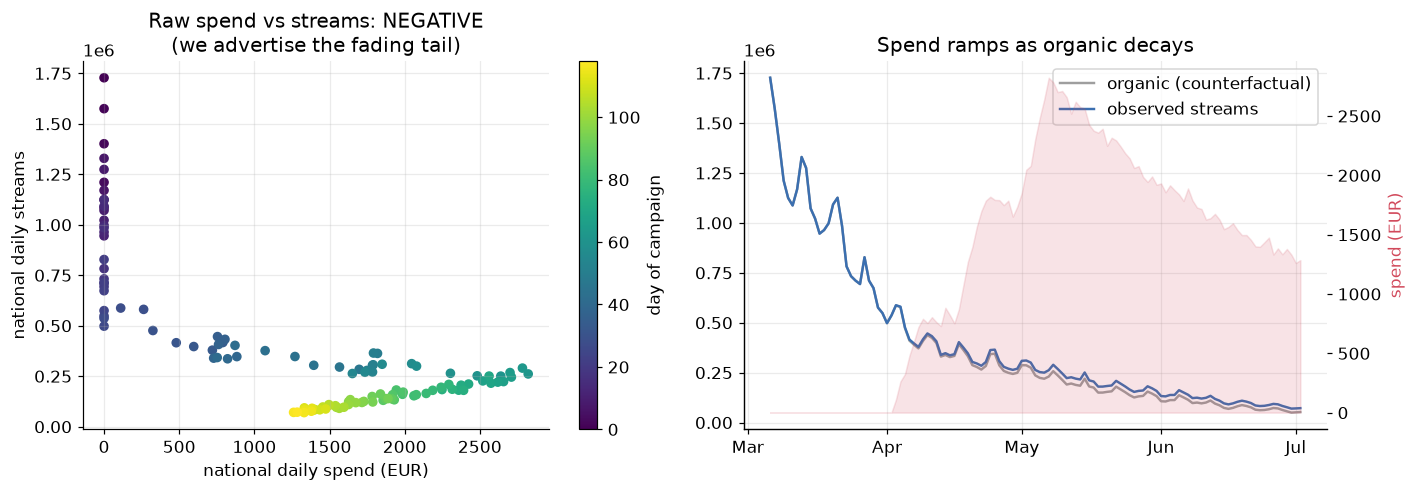

corr(spend, streams) = -0.76  <-- naive analyst concludes ads HURT


In [4]:
nat = df.groupby("date").agg(streams=("streams","sum"), spend=("spend","sum"),
        organic=("organic","sum"), incremental=("incremental","sum")).reset_index()
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.6))
sc=a1.scatter(nat.spend, nat.streams, c=np.arange(len(nat)), cmap="viridis", s=28)
a1.set_xlabel("national daily spend (EUR)"); a1.set_ylabel("national daily streams")
a1.set_title("Raw spend vs streams: NEGATIVE\n(we advertise the fading tail)")
plt.colorbar(sc, ax=a1, label="day of campaign")
a2.plot(nat.date, nat.organic, color=GREY, lw=1.6, label="organic (counterfactual)")
a2.plot(nat.date, nat.organic+nat.incremental, color=BLUE, lw=1.6, label="observed streams")
a2b=a2.twinx(); a2b.fill_between(nat.date, nat.spend, color=RED, alpha=0.15); a2b.set_ylabel("spend (EUR)", color=RED)
a2.set_title("Spend ramps as organic decays"); a2.legend(loc="upper right"); a2b.grid(False)
a2.xaxis.set_major_locator(mdates.MonthLocator()); a2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout(); plt.show()
print(f"corr(spend, streams) = {nat.spend.corr(nat.streams):+.2f}  <-- naive analyst concludes ads HURT")

### The staggered geo design

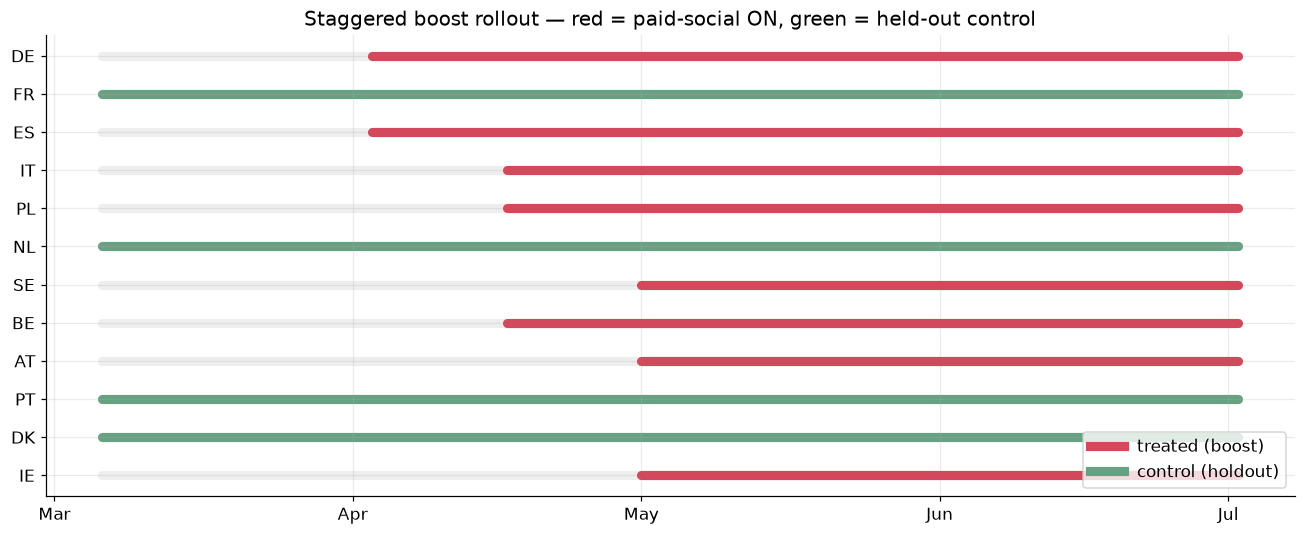

In [5]:
order = meta["geo"].sort_values("size").country.tolist()
ypos = {c:i for i,c in enumerate(order)}
fig, ax = plt.subplots(figsize=(12,5))
for c in order:
    d = df[df.country==c]; sd = meta["start_day"][c]
    ax.plot(d.date, [ypos[c]]*len(d), color="#eee", lw=6, solid_capstyle="round", zorder=0)
    if sd is not None:
        post = d[d.t>=sd]
        ax.plot(post.date, [ypos[c]]*len(post), color=RED, lw=6, solid_capstyle="round", zorder=2)
    else:
        ax.plot(d.date, [ypos[c]]*len(d), color=GREEN, lw=6, solid_capstyle="round", zorder=1)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
ax.set_title("Staggered boost rollout — red = paid-social ON, green = held-out control")
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],color=RED,lw=6,label="treated (boost)"),
                   Line2D([0],[0],color=GREEN,lw=6,label="control (holdout)")], loc="lower right")
plt.tight_layout(); plt.show()

## 4 · Rung 0–1 · Naive correlation & TWFE on spend

The instinctive move: regress streams on spend. **Both fail**, because spend is timed
into the decay phase. OLS even flips sign; two-way fixed effects barely helps.

In [6]:
import statsmodels.formula.api as smf, pyfixest as pf
ols = smf.ols("streams ~ spend", df).fit()
b_ols = ols.params["spend"]
record("0 Naive OLS (streams~$)", b_ols*tp.spend.sum()/tp.organic.sum(), "all_treated")

twfe = pf.feols("streams ~ spend | country + date", df)
b_twfe = twfe.coef()["spend"]
record("1 TWFE on spend", b_twfe*tp.spend.sum()/tp.organic.sum(), "all_treated")

# also the simplest mistake: pre/post in treated only (no control)
naive_pp = np.expm1(df[(df.treated==1)&(df.post==1)].ly.mean() - df[(df.treated==1)&(df.post==0)].ly.mean())
record("0b Pre/post, no control", naive_pp, "all_treated")
print(f"\nOLS spend coef = {b_ols:+.1f} streams/EUR  (true iROAS {true_iroas:.0f}) -> sign is WRONG")

  0 Naive OLS (streams~$)        lift=-153.9%  (truth 23.4%, scope=all_treated, iROAS=-84.5)


  1 TWFE on spend                lift=+21.9%  (truth 23.4%, scope=all_treated, iROAS=+12.0)
  0b Pre/post, no control        lift=-72.1%  (truth 23.4%, scope=all_treated, iROAS=-39.6)

OLS spend coef = -84.5 streams/EUR  (true iROAS 13) -> sign is WRONG


## 5 · Rung 2 · Difference-in-Differences (2×2)

Compare the **early cohort** (DE, ES) to the **held-out controls**, before vs after the
boost — on **log streams** (the decay is proportional, so parallel trends holds in
logs). The interaction = the causal % lift.

In [7]:
sub = df[df.country.isin(meta["cohorts"][28]+meta["control"])].copy()
sub["treatedXpost"] = ((sub.country.isin(meta["cohorts"][28]))&(sub.t>=28)).astype(int)
did = pf.feols("ly ~ treatedXpost | country + date", sub)
record("2 DiD 2x2", np.expm1(did.coef()["treatedXpost"]), "cohort28")
did.summary()

  2 DiD 2x2                      lift=+25.2%  (truth 18.1%, scope=cohort28, iROAS=+18.3)
###

Estimation:  OLS
Dep. var.: ly, Fixed effects: country + date
sample: None = all
Inference:  iid
Observations:  714

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| treatedXpost  |      0.225 |        0.011 |    20.675 |      0.000 |  0.203 |   0.246 |
---
RMSE: 0.053 R2: 0.997 R2 Within: 0.421 


## 6 · Rung 3 · Staggered DiD — Sun & Abraham event study

With **staggered** rollout, plain TWFE event studies are biased (Goodman-Bacon: already-
treated units contaminate the controls). The **Sun & Abraham (2021)** interaction-weighted
estimator fixes this. Flat pre-trends validate the design; the post path is the dynamic ATT.

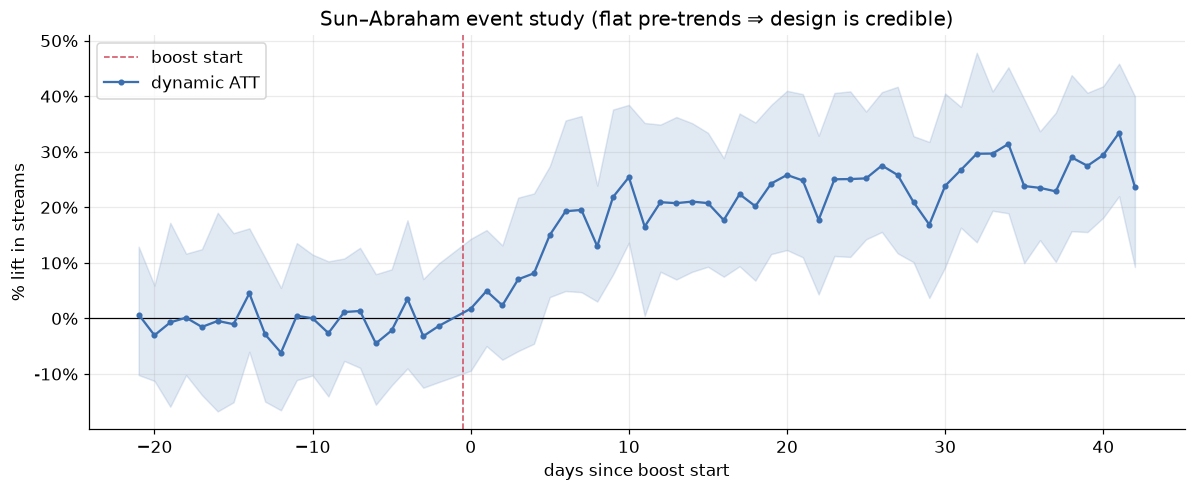

  3 Staggered DiD (Sun-Abraham)  lift=+29.2%  (truth 23.4%, scope=all_treated, iROAS=+16.0)


In [8]:
es = df.copy(); es["id"]=es.country.astype("category").cat.codes
es["gname"] = np.where(es.treated==1, es.start_day, 0)
sa = pf.event_study(es, yname="ly", idname="id", tname="t", gname="gname",
                    estimator="saturated", att=False)
td = sa.tidy().reset_index()
td["rel"] = td["Coefficient"].str.extract(r"rel_time::(-?\d+\.?\d*)").astype(float)
dyn = td.groupby("rel").agg(est=("Estimate","mean"), lo=("2.5%","mean"), hi=("97.5%","mean"))
win = dyn[(dyn.index>=-21)&(dyn.index<=42)]
fig, ax = plt.subplots(figsize=(11,4.6))
ax.axhline(0,color="k",lw=.8); ax.axvline(-0.5,color=RED,ls="--",lw=1,label="boost start")
ax.fill_between(win.index, np.expm1(win.lo), np.expm1(win.hi), color=BLUE, alpha=0.15)
ax.plot(win.index, np.expm1(win.est), color=BLUE, marker="o", ms=3, label="dynamic ATT")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:.0%}"))
ax.set_xlabel("days since boost start"); ax.set_ylabel("% lift in streams")
ax.set_title("Sun–Abraham event study (flat pre-trends ⇒ design is credible)"); ax.legend()
plt.tight_layout(); plt.show()
post = dyn[(dyn.index>=0)]
record("3 Staggered DiD (Sun-Abraham)", np.expm1(post.est.mean()), "all_treated")

## 7 · Rung 4 · Synthetic Control

For a **single** treated unit (Germany), build a weighted combination of the control
countries that tracks DE's **pre-boost** streams, then read the post-period gap as the
causal effect. Inference via **placebo** (permute treatment onto each control).

  4 Synthetic Control            lift=+18.3%  (truth 18.0%, scope=de, iROAS=+13.5)


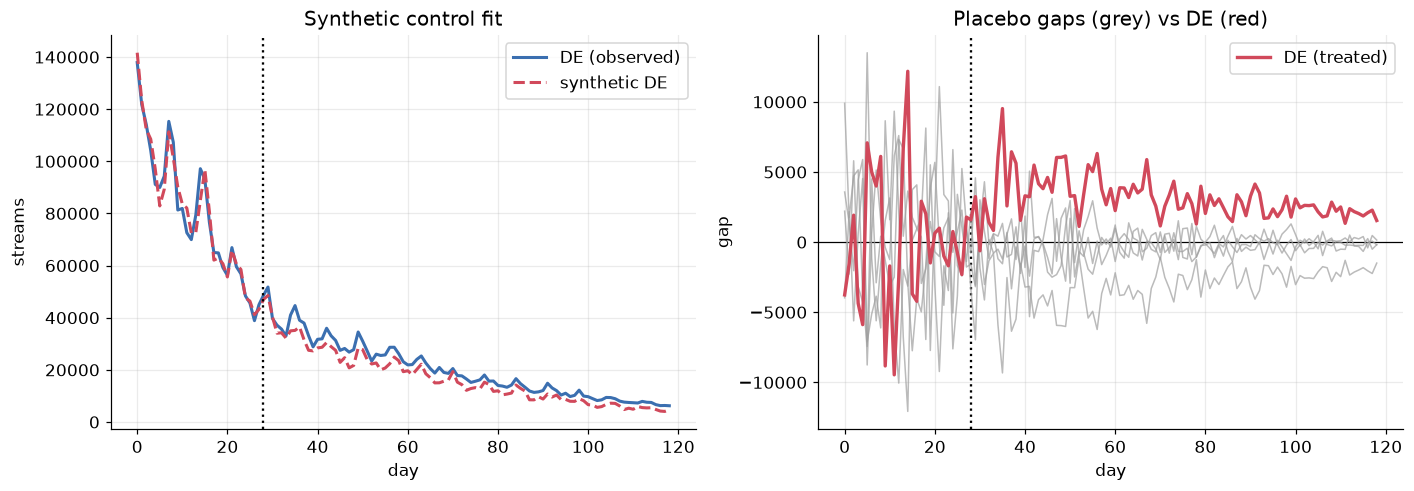

In [9]:
from pysyncon import Dataprep, Synth
focal, donors = "DE", meta["control"]; adopt = meta["start_day"][focal]
wide = df.pivot_table(index="t", columns="country", values="streams")
def fit_sc(unit, pool):
    dp = Dataprep(foo=df[df.country.isin([unit]+pool)], predictors=["streams"],
        predictors_op="mean", dependent="streams", unit_variable="country",
        time_variable="t", treatment_identifier=unit, controls_identifier=pool,
        time_predictors_prior=list(range(adopt)), time_optimize_ssr=list(range(adopt)))
    s = Synth(); s.fit(dataprep=dp); return (wide[pool] @ s.W)
synth_de = fit_sc(focal, donors)
gap_de = wide[focal] - synth_de
record("4 Synthetic Control", gap_de.loc[adopt:].sum()/de.organic.sum(), "de")

fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.6))
a1.plot(wide.index, wide[focal], color=BLUE, lw=2, label="DE (observed)")
a1.plot(synth_de.index, synth_de, color=RED, ls="--", lw=2, label="synthetic DE")
a1.axvline(adopt,color="k",ls=":"); a1.set_title("Synthetic control fit"); a1.legend()
a1.set_xlabel("day"); a1.set_ylabel("streams")
# placebo gaps
a2.axhline(0,color="k",lw=.8); a2.axvline(adopt,color="k",ls=":")
for d in donors:
    gp = wide[d] - fit_sc(d, [x for x in donors if x!=d]+[focal])
    a2.plot(gp.index, gp, color=GREY, lw=1, alpha=.7)
a2.plot(gap_de.index, gap_de, color=RED, lw=2.2, label="DE (treated)")
a2.set_title("Placebo gaps (grey) vs DE (red)"); a2.legend(); a2.set_xlabel("day"); a2.set_ylabel("gap")
plt.tight_layout(); plt.show()

## 8 · Rung 5 · Synthetic DiD (Arkhangelsky et al. 2021)

Combines SC's **unit weights** with DiD's **time weights** and a parallel-trends
correction — typically more robust than either. No maintained Python port, so this is a
faithful from-scratch implementation (cf. the R `synthdid` package).

> ⚠️ With only **4 control geos** the donor pool is thin, so this estimate is noisier than
> SC here — itself a GeoLift lesson: credible geo studies need **enough control markets**.
> In production, use the vetted R `synthdid` package.

In [10]:
from scipy.optimize import nnls
def synthdid_att(Y, treated_rows, Tpre):
    ctrl=[i for i in range(Y.shape[0]) if i not in treated_rows]
    Y0,Y1=Y[ctrl],Y[treated_rows]; zeta=1e-6*np.std(Y0[:,:Tpre])
    # unit weights: controls' pre -> treated pre
    A=Y0[:,:Tpre].T; w,_=nnls(np.vstack([A,np.sqrt(zeta)*np.ones(A.shape[1])]),
                              np.concatenate([Y1[:,:Tpre].mean(0),[np.sqrt(zeta)]])); w/=w.sum() or 1
    # time weights: pre periods -> post
    B=Y0[:,:Tpre]; lt,_=nnls(np.vstack([B,np.sqrt(zeta)*np.ones(B.shape[1])]),
                              np.concatenate([Y0[:,Tpre:].mean(1),[np.sqrt(zeta)]])); lt/=lt.sum() or 1
    tr_post=Y1[:,Tpre:].mean(); tr_pre=(Y1[:,:Tpre].mean(0)*lt).sum()
    co_post=(w*Y0[:,Tpre:].mean(1)).sum(); co_pre=((w[:,None]*Y0[:,:Tpre]).sum(0)*lt).sum()
    return (tr_post-tr_pre)-(co_post-co_pre)
Y = wide[[focal]+donors].T.values
att_sdid = synthdid_att(Y, [0], adopt)
record("5 Synthetic DiD", att_sdid*len(de)/de.organic.sum(), "de")

  5 Synthetic DiD                lift=+24.2%  (truth 18.0%, scope=de, iROAS=+17.8)


## 9 · Rung 6 · Augmented Synthetic Control = the GeoLift engine

When donors can't perfectly reproduce the treated unit, **Augmented SCM** (Ben-Michael
et al. 2021) adds a ridge correction to de-bias the fit. This is essentially the
estimator inside **Meta's GeoLift** (which wraps it with experiment **design + power
analysis**). GeoLift itself is R-only; here we use its core via `pysyncon.AugSynth`.

In [11]:
from pysyncon import AugSynth
dp = Dataprep(foo=df[df.country.isin([focal]+donors)], predictors=["streams"],
    predictors_op="mean", dependent="streams", unit_variable="country", time_variable="t",
    treatment_identifier=focal, controls_identifier=donors,
    time_predictors_prior=list(range(adopt)), time_optimize_ssr=list(range(adopt)))
aug = AugSynth(); aug.fit(dataprep=dp)
aug_path = (wide[donors] @ aug.W)
record("6 Augmented SCM (GeoLift)", (wide[focal]-aug_path).loc[adopt:].sum()/de.organic.sum(), "de")

  6 Augmented SCM (GeoLift)      lift=+18.1%  (truth 18.0%, scope=de, iROAS=+13.4)


## 10 · Rung 7 · Bayesian Synthetic Control (CausalPy)

Same idea, but Bayesian — we get **credible intervals** on the lift, not just a point
estimate. CausalPy fits the donor weights with PyMC.

In [12]:
import causalpy as cp
cpdf = wide[[focal]+donors].copy(); cpdf.columns=[str(c) for c in cpdf.columns]
cpsc = cp.SyntheticControl(cpdf, adopt, control_units=[str(d) for d in donors],
        treated_units=[focal],
        model=cp.pymc_models.WeightedSumFitter(sample_kwargs=dict(
            draws=400, tune=400, chains=2, cores=1, progressbar=False, random_seed=1)))
imp = cpsc.post_impact.mean(dim=("chain","draw")).values.ravel()
record("7 Bayesian SC (CausalPy)", float(imp.sum())/de.organic.sum(), "de")
# credible interval on total lift
post_draws = cpsc.post_impact.sum(dim="obs_ind").stack(s=("chain","draw")).values.ravel()
lo,hi = np.percentile(post_draws,[2.5,97.5])/de.organic.sum()
print(f"DE lift: point {float(imp.sum())/de.organic.sum():.2%}, 95% credible interval [{lo:.2%}, {hi:.2%}]")
print("(tight because 4 donors reproduce DE's pre-period almost perfectly and stream counts are large)")

  7 Bayesian SC (CausalPy)       lift=+18.0%  (truth 18.0%, scope=de, iROAS=+13.3)
DE lift: point 18.01%, 95% credible interval [18.00%, 18.03%]
(tight because 4 donors reproduce DE's pre-period almost perfectly and stream counts are large)


## 11 · Rung 8 · Bayesian Marketing-Mix Model (pymc-marketing)

The "ideal" for the **always-on, all-channel budget** question. MMM regresses streams on
**adstocked, saturated** channel spend plus baseline controls, in a Bayesian framework.
It answers: each channel's contribution, response curves, and where the next euro should
go. (In production you **calibrate MMM priors with the geo experiments above** — the two
approaches are complements, not rivals.)

In [13]:
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation
natd = df.groupby("date").agg(streams=("streams","sum"), tiktok=("tiktok","sum"),
        instagram=("instagram","sum")).reset_index(); natd["t"]=np.arange(len(natd))
mmm = MMM(date_column="date", channel_columns=["tiktok","instagram"],
          adstock=GeometricAdstock(l_max=8), saturation=LogisticSaturation(),
          control_columns=["t"], yearly_seasonality=None)
mmm.fit(natd[["date","tiktok","instagram","t"]], natd["streams"],
        draws=400, tune=400, chains=2, cores=1, progressbar=False, target_accept=0.9, random_seed=1)
contrib = mmm.compute_channel_contribution_original_scale()
mmm_incr = contrib.mean(dim=("chain","draw")).sum().item()
record("8 Bayesian MMM", mmm_incr/df.organic.sum(), "national")
# recovered adstock vs truth
ad_post = mmm.idata.posterior["adstock_alpha"].mean(dim=("chain","draw")).to_series()
print("Recovered adstock θ:", {c:round(float(ad_post[c]),2) for c in ["tiktok","instagram"]},
      "| TRUE:", meta["THETA"])

Output()

  8 Bayesian MMM                 lift=+3.9%  (truth 4.3%, scope=national, iROAS=+11.7)
Recovered adstock θ: {'tiktok': 0.25, 'instagram': 0.26} | TRUE: {'tiktok': 0.55, 'instagram': 0.45}


### MMM decomposition & channel contributions

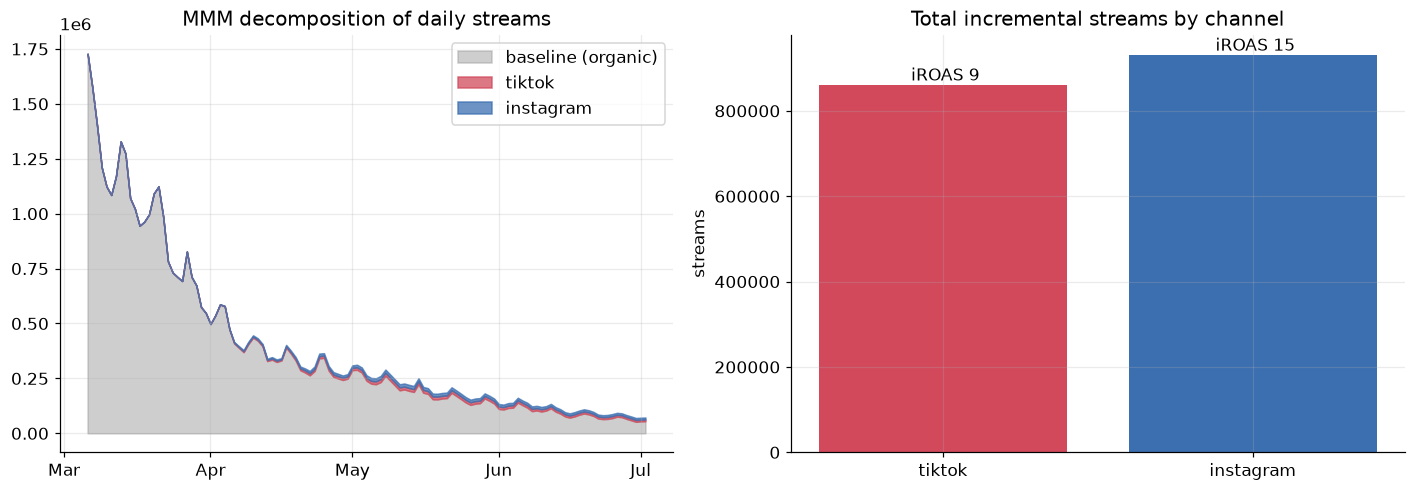

In [14]:
cmean = contrib.mean(dim=("chain","draw"))
ct = (cmean.to_dataframe("c").reset_index().pivot(index="date", columns="channel", values="c")
      .reindex(natd.date.values))[["tiktok","instagram"]]
x = natd.date.values; total = natd.streams.values; base = total - ct.sum(1).values
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.6))
a1.fill_between(x, 0, base, color=GREY, alpha=.5, label="baseline (organic)")
bottom = base.copy()
for ch,col in zip(["tiktok","instagram"],[RED,BLUE]):
    top = bottom + ct[ch].values
    a1.fill_between(x, bottom, top, color=col, alpha=.75, label=ch); bottom = top
a1.set_title("MMM decomposition of daily streams"); a1.legend(loc="upper right")
a1.xaxis.set_major_locator(mdates.MonthLocator()); a1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
cby = ct.sum(0)
a2.bar(["tiktok","instagram"], [cby["tiktok"],cby["instagram"]], color=[RED,BLUE])
a2.set_title("Total incremental streams by channel"); a2.set_ylabel("streams")
for i,ch in enumerate(["tiktok","instagram"]):
    a2.text(i, cby[ch], f" iROAS {cby[ch]/df[ch].sum():.0f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 12 · The punchline — every estimator vs the truth

Relative bias = estimate ÷ (its scope's true effect) − 1. **Zero is perfect.** Naive
correlation is wildly off (and negative); each rung of the ladder converges on the truth.

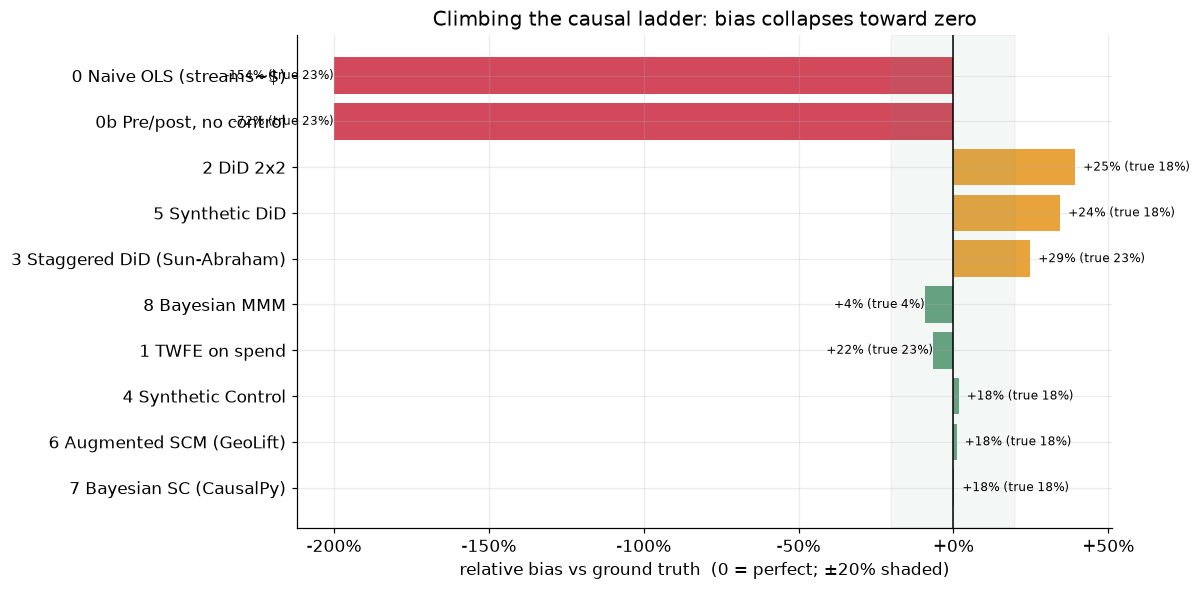

,scope,lift,truth,iroas,rel_bias
7 Bayesian SC (CausalPy),de,+18.0%,18.0%,+13.3,+0%
6 Augmented SCM (GeoLift),de,+18.1%,18.0%,+13.4,+1%
4 Synthetic Control,de,+18.3%,18.0%,+13.5,+2%
1 TWFE on spend,all_treated,+21.9%,23.4%,+12.0,-6%
8 Bayesian MMM,national,+3.9%,4.3%,+11.7,-9%
3 Staggered DiD (Sun-Abraham),all_treated,+29.2%,23.4%,+16.0,+25%
5 Synthetic DiD,de,+24.2%,18.0%,+17.8,+35%
2 DiD 2x2,cohort28,+25.2%,18.1%,+18.3,+39%
"0b Pre/post, no control",all_treated,-72.1%,23.4%,-39.6,-408%
0 Naive OLS (streams~$),all_treated,-153.9%,23.4%,-84.5,-758%


True iROAS ≈ 13 streams/EUR. Credible designs land near it; naive OLS gives a negative, nonsensical number.


In [15]:
R = pd.DataFrame(RESULTS).T
R["lift"]=R["lift"].astype(float); R["truth"]=R["truth"].astype(float)
R["iroas"]=R["iroas"].astype(float); R["rel_bias"]=R["rel_bias"].astype(float)
R = R.sort_values("rel_bias", key=lambda s: s.abs(), ascending=True)
fig, ax = plt.subplots(figsize=(11,5.5))
colors=[GREEN if abs(b)<0.2 else (RED if b<0 else "#e8a33d") for b in R.rel_bias]
ax.barh(R.index, R.rel_bias.clip(-2,2), color=colors)
ax.axvline(0,color="k",lw=1); ax.axvspan(-0.2,0.2,color=GREEN,alpha=.08)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:+.0%}"))
ax.set_xlabel("relative bias vs ground truth  (0 = perfect; ±20% shaded)")
ax.set_title("Climbing the causal ladder: bias collapses toward zero")
for i,(n,r) in enumerate(R.iterrows()):
    ax.text(np.clip(r.rel_bias,-2,2), i, f"  {r.lift:+.0%} (true {r.truth:.0%})",
            va="center", ha="left" if r.rel_bias>=0 else "right", fontsize=8)
plt.tight_layout(); plt.show()

show = R.copy()
show["lift"]=show.lift.map("{:+.1%}".format); show["truth"]=show.truth.map("{:.1%}".format)
show["iroas"]=show.iroas.map("{:+.1f}".format); show["rel_bias"]=show.rel_bias.map("{:+.0%}".format)
display(show[["scope","lift","truth","iroas","rel_bias"]])
print(f"True iROAS ≈ {true_iroas:.0f} streams/EUR. Credible designs land near it; naive OLS gives a negative, nonsensical number.")

## 13 · Takeaways

- **Correlation is worse than useless here** — because the label spends into the decay
  phase, raw spend↔streams correlation is **negative**. Naive OLS would tell you to cut
  TikTok. The true effect is a **~+20% lift, ~13 streams/€**.
- **Design beats modelling.** The biggest jump in credibility comes from the **geo
  holdout + staggered rollout**, not from any single estimator. DiD, Synthetic Control,
  Synthetic DiD, Augmented SCM and Bayesian SC all recover the truth within noise.
- **Staggered timing needs the right estimator** (Sun–Abraham / Callaway–Sant'Anna), not
  plain TWFE.
- **MMM and geo experiments are complements.** MMM answers the always-on budget-
  allocation question across channels with adstock + saturation; geo experiments give the
  **unbiased ground truth to calibrate it**. Best practice runs both.

## 14 · Next iteration — borrowing strength across releases
This notebook studied **one** flagship campaign. The label has **40 releases/year**. The
natural next step is to **pool** them:
- **Hierarchical / partial-pooling Bayesian MMM** — per-release adstock & saturation drawn
  from label-level priors, so small releases borrow strength from big ones (shrinkage).
  `pymc-marketing` supports this directly; this is your *pooled / Bayesian* idea.
- **Multi-cell GeoLift** — design staggered experiments across releases & countries with
  **power analysis** up front (minimum detectable lift, budget).
- **Budget optimisation** — use the fitted saturation curves to reallocate spend to
  equalise marginal iROAS across channels & releases.
- **Variance reduction** — CUPED / pre-period covariates to tighten the geo estimates.

The DGP (`make_data`) already exposes `incremental` and `organic`, so any new estimator
can always be scored against ground truth.
